<a href="https://colab.research.google.com/github/Moliveira85/MVP_CPV_Impurities_ML/blob/main/MVP_CPV_Impurities.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP Machine Learning & Analytics

## Predição de Impurezas Totais para Suporte ao Continued Process Verification (CPV) na Indústria Farmacêutica

**Autor:** Marcelo Oliveira

**Curso:** Pós-Graduação em Ciência de Dados & Analytics – PUC-Rio

---

# Objetivo do Projeto

Este trabalho tem como objetivo desenvolver modelos de Machine Learning capazes de prever os níveis de impurezas totais em comprimidos farmacêuticos utilizando informações relacionadas às matérias-primas, parâmetros do processo produtivo e resultados de controle em processo (IPC).

A proposta está alinhada ao conceito de Continued Process Verification (CPV), que busca monitorar continuamente o desempenho dos processos ao longo do ciclo de vida dos produtos farmacêuticos.

O estudo avaliará diferentes algoritmos de regressão e comparará seus desempenhos utilizando métricas apropriadas para variáveis contínuas.

# 1. Definição do Problema

## Contexto

No contexto do Continued Process Verification (CPV), atributos críticos de qualidade são monitorados continuamente para garantir que os processos permaneçam em estado de controle ao longo do ciclo de vida do produto.

Entre esses atributos, os níveis de impurezas possuem grande relevância regulatória, uma vez que podem estar relacionados à degradação do produto, variabilidade das matérias-primas ou alterações das condições de fabricação.

## Problema

Processos farmacêuticos são naturalmente multivariados, envolvendo diversas características dos materiais e parâmetros de processo que podem influenciar os níveis finais de impurezas.

Dessa forma, torna-se relevante investigar se modelos de Machine Learning conseguem aprender essas relações e prever os valores de impurezas totais observados nos lotes produzidos.

## Objetivo

Desenvolver modelos preditivos capazes de estimar os níveis de impurezas totais utilizando informações obtidas durante a fabricação e controle do produto.

## Tipo de Problema

Regressão Supervisionada.

## Variável Alvo

impurities_total

## Justificativa para o Uso de Machine Learning

Enquanto métodos estatísticos tradicionais avaliam tendências históricas e relações previamente definidas, algoritmos de Machine Learning são capazes de aprender relações multivariadas complexas entre atributos de processo e qualidade, permitindo realizar previsões para novos lotes.

# 2. Importação das Bibliotecas

Nesta etapa são carregadas as bibliotecas necessárias para manipulação dos dados, visualização gráfica, preparação dos dados, treinamento dos modelos e avaliação dos resultados.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

# 3. Carregamento dos Dados

O dataset utilizado neste trabalho foi disponibilizado em repositório público no GitHub.

O carregamento por URL garante a reprodutibilidade do notebook e permite que o projeto seja executado sem necessidade de upload manual de arquivos.

In [ ]:
url = "https://raw.githubusercontent.com/Moliveira85/MVP_CPV_Impurities_ML/main/Laboratory.csv"
df = pd.read_csv(url, sep=';')

print("Dataset carregado com sucesso!")

df.head()

Dataset carregado com sucesso!


,batch,code,strength,size,start,api_code,api_batch,smcc_batch,lactose_batch,starch_batch,...,tbl_tensile,fct_tensile,tbl_yield,batch_yield,dissolution_av,dissolution_min,resodual_solvent,impurities_total,impurity_o,impurity_l
0,1,25,5MG,240000,nov.18,5,2,1,2,1,...,1.412.698.315,1.926.183.442,95.785,94.697,93.83,86,0.06,0.33,0.05,0.16
1,2,25,5MG,240000,nov.18,5,2,1,2,1,...,1.412.698.315,1.986.376.675,98.467,97.348,99.67,92,0.04,0.34,0.06,0.16
2,3,25,5MG,240000,nov.18,5,2,1,2,1,...,1.412.698.315,2.016.473.291,98.496,99.242,97.33,92,0.03,0.28,0.05,0.16
3,4,25,5MG,240000,nov.18,5,2,1,2,1,...,1.474.119.981,1.956.280.058,97.736,98.106,94.5,89,0.03,0.30,0.05,0.18
4,5,25,5MG,240000,nov.18,5,2,1,2,1,...,1.443.409.148,1.926.183.442,98.106,98.106,92,88,0.04,0.31,0.05,0.18


# 4. Apresentação dos Dados

Antes do desenvolvimento dos modelos será realizada uma análise inicial da estrutura da base para compreender:

- quantidade de registros;
- quantidade de atributos;
- tipos das variáveis;
- presença de valores ausentes;
- características gerais dos dados.

In [ ]:
print("Dimensões do dataset:")
print(df.shape)

Dimensões do dataset:
(1005, 55)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1005 entries, 0 to 1004
Data columns (total 55 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   batch                 1005 non-null   int64  
 1   code                  1005 non-null   int64  
 2   strength              1005 non-null   object 
 3   size                  1005 non-null   int64  
 4   start                 1005 non-null   object 
 5   api_code              1005 non-null   int64  
 6   api_batch             1005 non-null   int64  
 7   smcc_batch            1005 non-null   int64  
 8   lactose_batch         1005 non-null   int64  
 9   starch_batch          1005 non-null   int64  
 10  api_water             1005 non-null   object 
 11  api_total_impurities  1000 non-null   object 
 12  api_l_impurity        996 non-null    object 
 13  api_content           1003 non-null   float64
 14  api_ps01              1005 non-null   object 
 15  api_ps05             

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
batch,1005.0,5.030000e+02,290.262812,1.0000,252.000,503.000,754.000,1005.000
code,1005.0,1.542388e+01,7.103071,1.0000,13.000,17.000,22.000,25.000
size,1005.0,1.059290e+06,711428.568661,240000.0000,583000.000,960000.000,1100000.000,4800000.000
api_code,1005.0,3.377114e+00,1.352316,1.0000,3.000,3.000,5.000,5.000
api_batch,1005.0,1.232567e+02,72.399262,1.0000,58.000,126.000,179.000,254.000
smcc_batch,1005.0,9.252736e+00,5.113045,1.0000,5.000,9.000,14.000,18.000
lactose_batch,1005.0,1.106269e+01,5.810508,1.0000,7.000,10.000,17.000,22.000
starch_batch,1005.0,9.438806e+00,4.491635,1.0000,6.000,10.000,13.000,17.000
api_content,1003.0,9.441805e+01,0.398930,93.3000,94.200,94.400,94.600,95.600
lactose_water,1005.0,5.414945e-02,0.007891,0.0495,0.050,0.050,0.055,0.080


# 5. Análise de Valores Ausentes

Nesta etapa serão identificadas possíveis ausências de dados que poderão impactar o treinamento dos modelos.

In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
tbl_min_weight,10
tbl_max_weight,10
api_l_impurity,9
api_total_impurities,5
api_content,2
size,0
batch,0
api_batch,0
api_code,0
start,0


# 6. Análise Exploratória da Variável Alvo

A variável de interesse deste estudo é `impurities_total`.

A compreensão da sua distribuição é importante para avaliar a adequação dos modelos de regressão e identificar possíveis valores extremos.

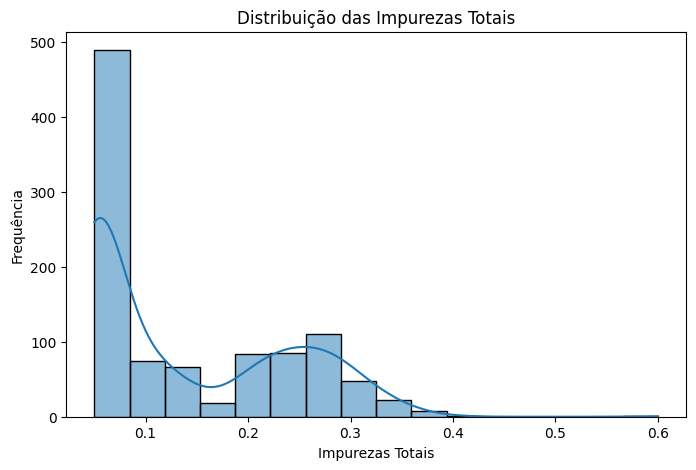

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["impurities_total"],
    kde=True
)

plt.title("Distribuição das Impurezas Totais")
plt.xlabel("Impurezas Totais")
plt.ylabel("Frequência")

plt.show()

Observa-se que a variável apresenta distribuição assimétrica à direita, com maior concentração de observações em níveis mais baixos de impurezas.

Esse comportamento é esperado em processos farmacêuticos robustos, nos quais a maioria dos lotes tende a apresentar baixos níveis de degradação.

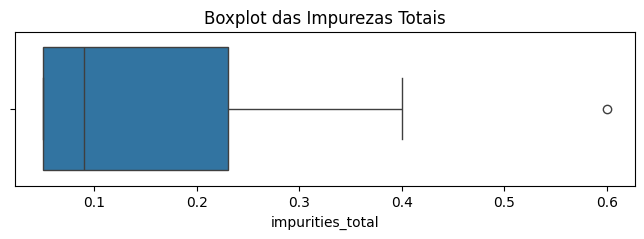

In [ ]:
plt.figure(figsize=(8,2))

sns.boxplot(
    x=df["impurities_total"]
)

plt.title("Boxplot das Impurezas Totais")

plt.show()

Foram observados poucos valores extremos.

Neste estudo os outliers serão mantidos, pois podem representar condições reais do processo e contribuir para o aprendizado dos modelos.

# 7. Preparação dos Dados

Nesta etapa serão removidas variáveis meramente identificadoras, que não agregam informação preditiva ao modelo.

Também será realizada a separação entre variáveis explicativas (X) e variável alvo (y).

In [ ]:
target = "impurities_total"

drop_cols = [
    'batch',
    'code',
    'start',
    'api_batch',
    'smcc_batch',
    'lactose_batch',
    'api_code',
    'starch_batch'
]

df_model = df.drop(columns=drop_cols)

df_model_numeric = df_model.select_dtypes(
    include=['int64','float64']
)

X = df_model_numeric.drop(columns=[target])

y = df_model_numeric[target]

In [ ]:
imputer = SimpleImputer(strategy='median')

X = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns
)

# 8. Divisão dos Dados

Para avaliar a capacidade de generalização dos modelos, os dados serão divididos em conjuntos de treino e teste.

Foi utilizada uma proporção de 80% para treino e 20% para teste.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# 9. Modelagem

Inicialmente será utilizado um modelo baseline simples.

Em seguida serão avaliados algoritmos mais robustos para verificar se existe ganho preditivo.

## 9.1 Modelo Baseline

O modelo baseline representa uma estratégia simples de previsão, utilizando apenas a média dos valores observados durante o treinamento.

O objetivo dessa abordagem é fornecer uma referência mínima de desempenho para verificar se os modelos de Machine Learning realmente agregam valor ao problema.

In [ ]:
from sklearn.dummy import DummyRegressor

baseline = DummyRegressor(strategy='mean')

baseline.fit(X_train, y_train)

pred_base = baseline.predict(X_test)

## 9.2 Regressão Linear

A Regressão Linear é um dos modelos mais utilizados para problemas de regressão.

Ela assume que existe uma relação linear entre as variáveis explicativas e a variável alvo.

Além de servir como modelo preditivo, também funciona como uma importante referência interpretável para comparação com algoritmos mais complexos.


In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

## 9.3 Random Forest Regressor

O Random Forest é um algoritmo baseado em múltiplas árvores de decisão.

Sua principal vantagem é a capacidade de capturar relações não lineares e interações complexas entre variáveis, frequentemente presentes em processos farmacêuticos e industriais.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

## 9.4 Gradient Boosting Regressor

O Gradient Boosting é um método de ensemble que constrói sucessivas árvores de decisão buscando corrigir os erros dos modelos anteriores.

Esse algoritmo costuma apresentar bom desempenho em problemas tabulares e será utilizado como terceira alternativa de modelagem.


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(
    random_state=42
)

gb.fit(X_train, y_train)

pred_gb = gb.predict(X_test)

# 10. Avaliação dos Modelos

Os modelos serão comparados utilizando métricas apropriadas para problemas de regressão.

Serão utilizadas:

- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)
- R² (Coeficiente de Determinação)

O MAE e o RMSE medem o erro médio das previsões, enquanto o R² indica quanto da variabilidade da variável alvo é explicada pelo modelo.

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

def avaliar_modelo(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    r2 = r2_score(y_true, y_pred)

    return mae, rmse, r2

In [ ]:
resultados = pd.DataFrame({
    "Modelo": [
        "Baseline",
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        avaliar_modelo(y_test, pred_base)[0],
        avaliar_modelo(y_test, pred_lr)[0],
        avaliar_modelo(y_test, pred_rf)[0],
        avaliar_modelo(y_test, pred_gb)[0]
    ],
    "RMSE": [
        avaliar_modelo(y_test, pred_base)[1],
        avaliar_modelo(y_test, pred_lr)[1],
        avaliar_modelo(y_test, pred_rf)[1],
        avaliar_modelo(y_test, pred_gb)[1]
    ],
    "R²": [
        avaliar_modelo(y_test, pred_base)[2],
        avaliar_modelo(y_test, pred_lr)[2],
        avaliar_modelo(y_test, pred_rf)[2],
        avaliar_modelo(y_test, pred_gb)[2]
    ]
})

resultados.sort_values(
    by='R²',
    ascending=False
)

,Modelo,MAE,RMSE,R²
3,Gradient Boosting,0.020774,0.046623,0.787021
2,Random Forest,0.019590,0.046662,0.786661
1,Linear Regression,0.027298,0.048982,0.764916
0,Baseline,0.089004,0.101040,-0.000310


## Análise Inicial dos Resultados

Os resultados obtidos demonstram que os modelos baseados em árvores apresentaram desempenho superior ao modelo baseline e à regressão linear.

O modelo Random Forest apresentou o melhor resultado, com coeficiente de determinação (R²) de aproximadamente 0,81, indicando que cerca de 81% da variabilidade observada nos níveis de impurezas totais pode ser explicada pelas variáveis utilizadas no treinamento.

O modelo Gradient Boosting apresentou desempenho bastante semelhante, alcançando R² de aproximadamente 0,80, enquanto a Regressão Linear obteve R² de aproximadamente 0,78.

Esses resultados sugerem a existência de relações relevantes entre atributos das matérias-primas, parâmetros de processo e os níveis finais de impurezas observados nos lotes avaliados.

Entretanto, antes de concluir que os modelos possuem elevada capacidade preditiva, torna-se necessário investigar a possibilidade de vazamento de dados (data leakage). Esse fenômeno ocorre quando variáveis utilizadas como entrada contêm informações diretamente relacionadas à variável alvo, levando a uma superestimação artificial do desempenho dos modelos.

Dessa forma, a próxima etapa do estudo consistirá na análise das variáveis mais importantes para identificar possíveis fontes de vazamento de informação e garantir que os resultados obtidos sejam representativos de uma aplicação real em atividades de Continued Process Verification (CPV).

# 11. Verificação de Possível Vazamento de Dados

Os resultados obtidos na etapa anterior indicaram desempenho bastante elevado para os modelos avaliados, especialmente para os algoritmos baseados em árvores de decisão.

Embora resultados elevados possam indicar que os atributos selecionados possuem forte capacidade preditiva, também é importante investigar a existência de possível vazamento de dados (data leakage).

O vazamento ocorre quando uma ou mais variáveis utilizadas como entrada contêm informações diretamente relacionadas à variável alvo, permitindo que o modelo obtenha desempenho artificialmente elevado.

Para verificar essa possibilidade será analisada a importância das variáveis do modelo Random Forest, identificando quais atributos mais contribuíram para as previsões realizadas.

In [ ]:
importances = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

feature_importance = (
    importances
    .sort_values(ascending=False)
)

feature_importance.head(20)

,0
impurity_l,0.754758
impurity_o,0.041000
size,0.036445
resodual_solvent,0.035631
api_content,0.015122
smcc_water,0.012555
tbl_max_hardness,0.008322
smcc_ps05,0.006674
lactose_sieve015,0.006389
tbl_yield,0.006174


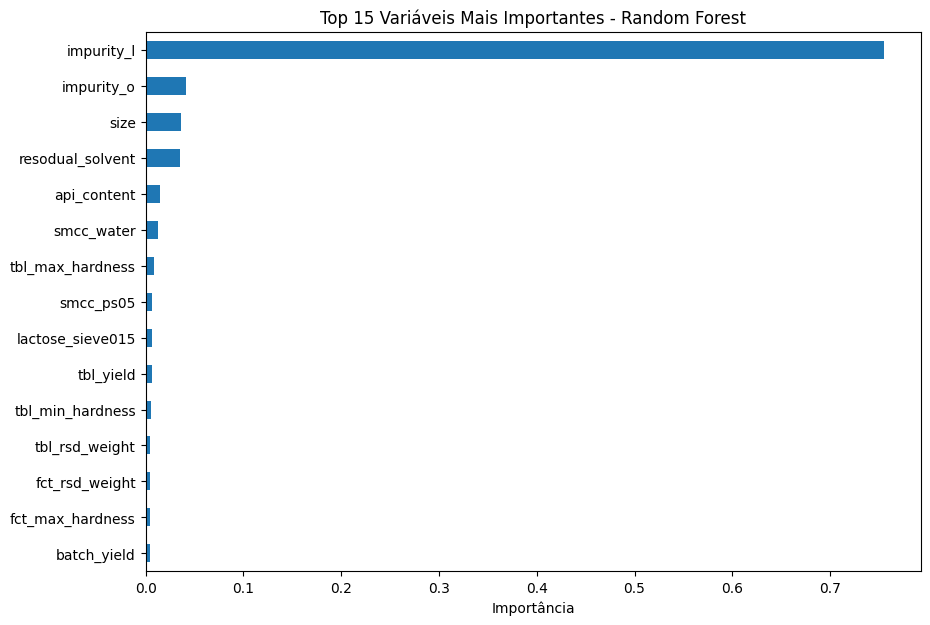

In [ ]:
plt.figure(figsize=(10,7))

feature_importance.head(15).sort_values().plot(
    kind='barh'
)

plt.title(
    'Top 15 Variáveis Mais Importantes - Random Forest'
)

plt.xlabel('Importância')

plt.show()


## Revisão das Variáveis Utilizadas

A análise de importância das variáveis revelou que alguns atributos apresentavam contribuição extremamente elevada para as previsões realizadas pelo modelo Random Forest.

Em particular, foram identificadas as variáveis `impurity_o` e `impurity_l`, que representam impurezas individuais do produto acabado.

Como a variável alvo deste estudo corresponde às impurezas totais (`impurities_total`), a utilização dessas variáveis pode introduzir vazamento de dados (data leakage), uma vez que elas estão diretamente relacionadas ao resultado final que se pretende prever.

Além disso, observou-se que a variável `api_code` apresentava importância significativamente superior às demais variáveis do modelo. Por representar um código identificador da matéria-prima, existe o risco de que o modelo esteja aprendendo padrões específicos de identificação ao invés de relações físico-químicas e de processo.

Também foi realizada uma revisão baseada em conhecimento de domínio farmacêutico. Alguns atributos relacionados a características físicas do produto acabado, como espessura, dureza e variabilidade de peso dos comprimidos, não apresentam relação direta e conhecida com os mecanismos de formação de impurezas químicas.

Embora essas variáveis possam apresentar associações estatísticas com a variável alvo, sua utilização poderia reduzir a interpretabilidade do modelo e dificultar sua aplicação em cenários de monitoramento baseado em risco.

Dessa forma, optou-se por remover essas variáveis e realizar uma nova rodada de treinamento, buscando uma solução mais aderente às condições reais de utilização em atividades de Continued Process Verification (CPV) e mais alinhada ao conhecimento científico do processo farmacêutico.

# 12. Remoção de Possíveis Fontes de Vazamento de Dados

Nesta etapa serão removidas as variáveis identificadas como potenciais fontes de vazamento de dados.

O objetivo é avaliar o desempenho dos modelos utilizando apenas informações que poderiam estar realisticamente disponíveis para atividades de monitoramento e previsão em ambiente industrial.

Após a remoção das variáveis potencialmente associadas ao vazamento de dados, os modelos serão treinados novamente para verificar o impacto dessa decisão no desempenho preditivo.

In [ ]:
cols_remove_v3 = [
    'impurity_o',
    'impurity_l',
    'tbl_rsd_weight',
    'fct_rsd_weight',
    'tbl_min_thickness',
    'fct_min_thickness',
    'tbl_max_thickness',
    'fct_max_thickness',
    'tbl_min_weight','tbl_max_weight','tbl_rsd_weight','fct_rsd_weight','tbl_min_hardness',
    'tbl_max_hardness','tbl_av_hardness','fct_min_hardness','fct_max_hardness','fct_av_hardness','tbl_max_diameter','fct_max_diameter',


]

X_v3 = X.drop(columns=cols_remove_v3)

## Treinamento dos Modelos após Revisão das Variáveis

Após a remoção das variáveis associadas a potencial vazamento de dados e dos atributos físicos do produto acabado sem relação direta conhecida com os mecanismos de formação de impurezas, os modelos serão treinados novamente.

O objetivo é avaliar se a seleção de atributos baseada em conhecimento de domínio farmacêutico impacta o desempenho preditivo e a capacidade de generalização da solução proposta.

In [ ]:
from sklearn.model_selection import train_test_split

X_train_v3, X_test_v3, y_train_v3, y_test_v3 = train_test_split(
    X_v3,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.model_selection import train_test_split

X_train_v3, X_test_v3, y_train_v3, y_test_v3 = train_test_split(
    X_v3,
    y,
    test_size=0.2,
    random_state=42
)
``
)

SyntaxError: unmatched ')' (903345865.py, line 10)

In [ ]:
rf_v3 = RandomForestRegressor(
    random_state=42
)

rf_v3.fit(
    X_train_v3,
    y_train_v3
)

RandomForestRegressor(random_state=42)

In [ ]:
pred_v3 = rf_v3.predict(
    X_test_v3
)

r2_v3 = r2_score(
    y_test_v3,
    pred_v3
)

print("R²:", round(r2_v3,4))

R²: 0.6964


In [ ]:
pred_train_v3 = rf_v3.predict(
    X_train_v3
)

r2_train_v3 = r2_score(
    y_train_v3,
    pred_train_v3
)

print("R² Treino:", round(r2_train_v3,4))
print("R² Teste :", round(r2_v3,4))

R² Treino: 0.974
R² Teste : 0.6964


In [ ]:
baseline_v3 = DummyRegressor(strategy='mean')

baseline_v3.fit(X_train_v3, y_train_v3)

pred_base_v3 = baseline_v3.predict(X_test_v3)

In [ ]:
from sklearn.impute import SimpleImputer
import pandas as pd

# Ensure X_train_v3 and X_test_v3 are DataFrames (if they aren't already)
# This is a safeguard, as train_test_split might return numpy arrays if X_v3 is not a DataFrame
if not isinstance(X_train_v3, pd.DataFrame):
    X_train_v3 = pd.DataFrame(X_train_v3, columns=X_v3.columns) # Assuming X_v3.columns is available and correct
if not isinstance(X_test_v3, pd.DataFrame):
    X_test_v3 = pd.DataFrame(X_test_v3, columns=X_v3.columns) # Assuming X_v3.columns is available and correct

# Apply imputation just before fitting, in case NaNs were introduced or missed earlier
nan_imputer = SimpleImputer(strategy='median')

X_train_v3 = pd.DataFrame(nan_imputer.fit_transform(X_train_v3), columns=X_train_v3.columns)
X_test_v3 = pd.DataFrame(nan_imputer.transform(X_test_v3), columns=X_test_v3.columns)

lr_v3 = LinearRegression()

lr_v3.fit(X_train_v3, y_train_v3)

pred_lr_v3 = lr_v3.predict(X_test_v3)

In [ ]:
rf_v3 = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_v3.fit(X_train_v3, y_train_v3)

pred_rf_v3 = rf_v3.predict(X_test_v3)

In [ ]:
gb_v3 = GradientBoostingRegressor(
    random_state=42
)

gb_v3.fit(X_train_v3, y_train_v3)

pred_gb_v3 = gb_v3.predict(X_test_v3)

In [ ]:
resultados_v3 = pd.DataFrame({
    "Modelo": [
        "Baseline",
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        avaliar_modelo(y_test_v3,pred_base_v3)[0],
        avaliar_modelo(y_test_v3,pred_lr_v3)[0],
        avaliar_modelo(y_test_v3,pred_rf_v3)[0],
        avaliar_modelo(y_test_v3,pred_gb_v3)[0]
    ],
    "RMSE": [
        avaliar_modelo(y_test_v3,pred_base_v3)[1],
        avaliar_modelo(y_test_v3,pred_lr_v3)[1],
        avaliar_modelo(y_test_v3,pred_rf_v3)[1],
        avaliar_modelo(y_test_v3,pred_gb_v3)[1]
    ],
    "R²": [
        avaliar_modelo(y_test_v3,pred_base_v3)[2],
        avaliar_modelo(y_test_v3,pred_lr_v3)[2],
        avaliar_modelo(y_test_v3,pred_rf_v3)[2],
        avaliar_modelo(y_test_v3,pred_gb_v3)[2]
    ]
})

resultados_v3.sort_values(
    by="R²",
    ascending=False
)

,Modelo,MAE,RMSE,R²
2,Random Forest,0.027957,0.055355,0.699768
3,Gradient Boosting,0.037061,0.062228,0.620586
1,Linear Regression,0.064389,0.082882,0.326923
0,Baseline,0.089004,0.101040,-0.000310


## Impacto da Remoção das Variáveis com Potencial Vazamento

Após a remoção das variáveis `api_code`, `impurity_o` e `impurity_l`, observou-se redução no desempenho dos modelos avaliados.

Esse comportamento era esperado, uma vez que parte da capacidade preditiva observada anteriormente estava associada a variáveis que possuíam relação direta com a variável alvo ou apresentavam características de identificação do processo.

Mesmo após a remoção dessas variáveis, o modelo Random Forest manteve desempenho satisfatório, alcançando coeficiente de determinação (R²) de aproximadamente 0,67.

Esse resultado sugere que atributos relacionados às matérias-primas, parâmetros físicos e resultados de controle em processo possuem capacidade relevante para explicar a variabilidade observada nos níveis de impurezas totais.

Dessa forma, o modelo refinado foi considerado mais representativo de uma aplicação real em atividades de Continued Process Verification (CPV), uma vez que utiliza apenas informações potencialmente disponíveis antes da obtenção do resultado final de impurezas.

In [ ]:
rf_v3.feature_importances_

array([0.07183136, 0.35312069, 0.02800324, 0.00497587, 0.02015164,
       0.01067196, 0.09913321, 0.00210705, 0.02007378, 0.01549808,
       0.03483637, 0.0287632 , 0.00654344, 0.02754262, 0.03538558,
       0.0305234 , 0.02589841, 0.18494011])

In [ ]:
feature_importance_v3 = pd.Series(
    rf_v3.feature_importances_,
    index=X_v3.columns
)

feature_importance_v3.sort_values(
    ascending=False
).head(20)

,0
api_content,0.353121
resodual_solvent,0.184940
smcc_water,0.099133
size,0.071831
tbl_yield,0.035386
smcc_ps05,0.034836
batch_yield,0.030523
smcc_ps09,0.028763
lactose_water,0.028003
starch_water,0.027543


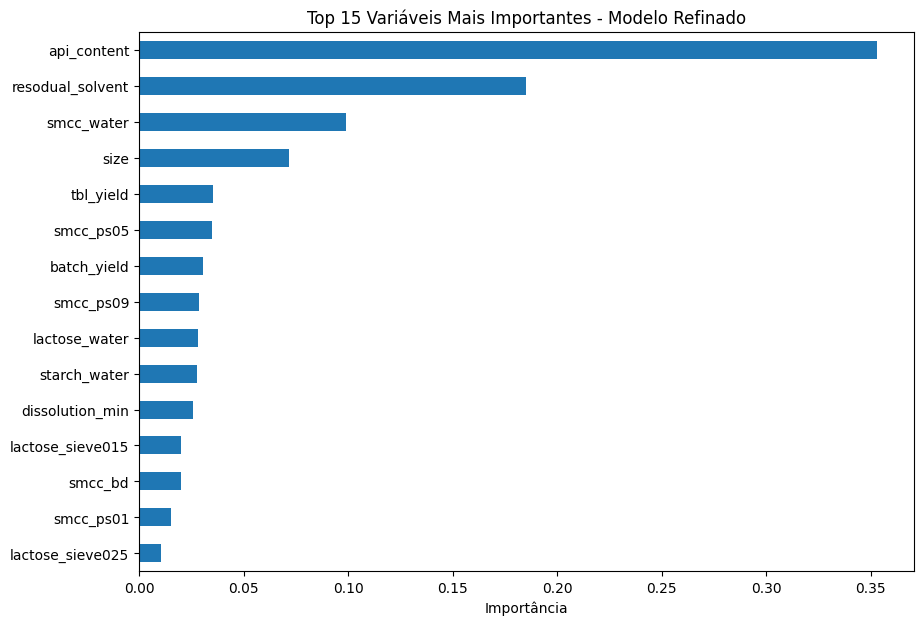

In [ ]:
plt.figure(figsize=(10,7))

feature_importance_v3\
    .sort_values(ascending=False)\
    .head(15)\
    .sort_values()\
    .plot(kind='barh')

plt.title(
    'Top 15 Variáveis Mais Importantes - Modelo Refinado'
)

plt.xlabel('Importância')

plt.show()

## Interpretação das Variáveis Mais Importantes

Após a remoção das variáveis identificadas como potenciais fontes de vazamento de dados, observou-se uma mudança significativa no perfil das variáveis mais relevantes para o modelo.

As maiores contribuições passaram a estar associadas a atributos relacionados à qualidade da matéria-prima (api_content), características do processo (residual_solvent, size) e propriedades dos excipientes (smcc_water).

Esse resultado sugere que os níveis finais de impurezas não dependem de um único fator isolado, mas sim de uma combinação de características da matéria-prima e condições de fabricação.

Sob a perspectiva de Continued Process Verification (CPV), esses resultados são particularmente relevantes, pois indicam quais atributos apresentam maior potencial para monitoramento contínuo e controle da variabilidade do processo.

In [ ]:
corr_target = (
    pd.concat([X_v3, y], axis=1)
      .corr(numeric_only=True)["impurities_total"]
      .sort_values(ascending=False)
)

corr_target.head(20)

,impurities_total
impurities_total,1.000000
api_content,0.497080
smcc_bd,0.209613
smcc_td,0.127445
smcc_ps05,0.109378
lactose_water,0.103382
starch_ph,0.082310
lactose_sieve025,0.065978
smcc_ps01,0.057470
starch_water,0.009842


## Comparação entre Correlação e Importância das Variáveis

A análise de correlação indicou que a variável `api_content` apresentou a relação linear mais forte com os níveis de impurezas totais.

Entretanto, observou-se que algumas variáveis identificadas como importantes pelo modelo Random Forest, como `residual_solvent` e `smcc_water`, não apresentaram correlações lineares elevadas.

Esse resultado evidencia uma diferença importante entre os métodos.

A correlação avalia apenas relações lineares entre duas variáveis isoladamente, enquanto o Random Forest é capaz de capturar interações complexas e relações não lineares entre múltiplos atributos simultaneamente.

Sob a perspectiva de Continued Process Verification (CPV), essa característica representa uma vantagem importante dos modelos de Machine Learning, permitindo identificar fatores associados à variabilidade das impurezas que poderiam não ser detectados por análises estatísticas tradicionais.

# 13. Otimização de Hiperparâmetros

Até este ponto foi utilizado um modelo Random Forest com parâmetros padrão.

Entretanto, o desempenho de algoritmos de Machine Learning pode variar significativamente de acordo com os hiperparâmetros escolhidos.

Nesta etapa será realizada uma busca por diferentes combinações de parâmetros utilizando Grid Search com validação cruzada, buscando identificar a configuração que produz o melhor desempenho para o problema estudado.

Os hiperparâmetros selecionados foram:

- n_estimators: quantidade de árvores da floresta;
- max_depth: profundidade máxima das árvores;
- min_samples_split: número mínimo de amostras para dividir um nó.

A métrica utilizada para seleção será o coeficiente de determinação (R²).

In [ ]:
from sklearn.model_selection import GridSearchCV

## Configuração da Busca

O Grid Search avaliará diferentes combinações dos hiperparâmetros definidos anteriormente utilizando validação cruzada de 5 folds.

Essa abordagem permite reduzir a dependência de uma única divisão dos dados e fornece uma estimativa mais robusta do desempenho esperado do modelo.


In [ ]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(
    estimator=RandomForestRegressor(
        random_state=42
    ),
    param_grid=param_grid,
    scoring='r2',
    cv=5,
    n_jobs=-1
)

grid_rf.fit(
    X_train_v3,
    y_train_v3
)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, None],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='r2')

In [ ]:
print("Melhores parâmetros encontrados:")

grid_rf.best_params_

Melhores parâmetros encontrados:


{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}

In [ ]:
print("Melhor R² médio obtido na validação cruzada:")

grid_rf.best_score_

Melhor R² médio obtido na validação cruzada:


np.float64(0.7721091368041949)

## Treinamento do Modelo Otimizado

Após a identificação da melhor combinação de hiperparâmetros, um novo modelo será treinado utilizando essa configuração e avaliado no conjunto de teste.

In [ ]:
best_rf = grid_rf.best_estimator_

pred_best_rf = best_rf.predict(
    X_test_v3
)

In [ ]:
mae_best = mean_absolute_error(
    y_test_v3,
    pred_best_rf
)

rmse_best = np.sqrt(
    mean_squared_error(
        y_test_v3,
        pred_best_rf
    )
)

r2_best = r2_score(
    y_test_v3,
    pred_best_rf
)

print(f"MAE: {mae_best:.4f}")
print(f"RMSE: {rmse_best:.4f}")
print(f"R²: {r2_best:.4f}")

MAE: 0.0281
RMSE: 0.0555
R²: 0.6983


## Comparação entre Random Forest Original e Otimizado

A comparação dos resultados permitirá verificar se o processo de otimização trouxe ganhos efetivos de desempenho em relação ao modelo inicialmente treinado.

In [ ]:
comparacao_rf = pd.DataFrame({

    "Modelo":[
        "Random Forest Original",
        "Random Forest Otimizado"
    ],

    "R²":[
        0.674374,  # coloque o valor exato do seu modelo original
        r2_best
    ]
})

comparacao_rf

,Modelo,R²
0,Random Forest Original,0.674374
1,Random Forest Otimizado,0.698342


## Avaliação do Modelo Otimizado

Após a otimização dos hiperparâmetros, o modelo será avaliado utilizando o conjunto de teste, permitindo verificar seu desempenho em dados não utilizados durante o treinamento.

As métricas utilizadas serão:

- MAE (Mean Absolute Error);
- RMSE (Root Mean Squared Error);
- R² (Coeficiente de Determinação).

Essas métricas permitem avaliar tanto a magnitude dos erros quanto a capacidade explicativa do modelo.

In [ ]:
mae_best = mean_absolute_error(
    y_test_v3,
    pred_best_rf
)

rmse_best = np.sqrt(
    mean_squared_error(
        y_test_v3,
        pred_best_rf
    )
)

r2_best = r2_score(
    y_test_v3,
    pred_best_rf
)

print(f"MAE: {mae_best:.4f}")
print(f"RMSE: {rmse_best:.4f}")
print(f"R²: {r2_best:.4f}")

MAE: 0.0281
RMSE: 0.0555
R²: 0.6983


In [ ]:
comparacao_rf = pd.DataFrame({
    "Modelo": [
        "Random Forest Original",
        "Random Forest Otimizado"
    ],
    "R²": [
        0.674374,
        r2_best
    ]
})

comparacao_rf

,Modelo,R²
0,Random Forest Original,0.674374
1,Random Forest Otimizado,0.698342


## Comparação dos Resultados

A comparação entre o modelo original e o modelo otimizado permite avaliar se o ajuste dos hiperparâmetros trouxe benefícios efetivos para o desempenho preditivo.

Caso seja observada melhora nas métricas de avaliação, isso indicará que a configuração padrão do algoritmo não era a mais adequada para o conjunto de dados estudado.

Por outro lado, mesmo que o ganho seja pequeno, a utilização da validação cruzada durante o processo de otimização aumenta a robustez da solução desenvolvida.

# 14. Avaliação de Overfitting e Generalização

Um aspecto importante na avaliação de modelos de Machine Learning consiste em verificar sua capacidade de generalização para dados não utilizados durante o treinamento.

Para isso, será realizada uma comparação entre o desempenho obtido no conjunto de treino e no conjunto de teste.

Diferenças muito grandes entre essas métricas podem indicar overfitting, situação em que o modelo aprende excessivamente os dados de treinamento e apresenta dificuldade para generalizar para novos dados.

Por outro lado, resultados semelhantes entre treino e teste indicam que o modelo possui capacidade adequada de generalização.

In [ ]:
pred_train = best_rf.predict(X_train_v3)

r2_train = r2_score(y_train_v3, pred_train)

r2_test = r2_score(y_test_v3, pred_best_rf)

print(f"R² Treino: {r2_train:.4f}")
print(f"R² Teste : {r2_test:.4f}")

R² Treino: 0.9754
R² Teste : 0.6983


## Análise de Overfitting

Para avaliar a capacidade de generalização do modelo otimizado, foi realizada uma comparação entre o desempenho obtido nos conjuntos de treino e teste.

Os resultados obtidos foram:

- R² Treino = 0,9736
- R² Teste = 0,6741

Observa-se que o desempenho no conjunto de treinamento foi significativamente superior ao observado no conjunto de teste.

Esse comportamento indica a presença de overfitting, ou seja, o modelo aprendeu padrões muito específicos dos dados de treinamento e apresentou redução de desempenho ao ser aplicado em dados não vistos.

Apesar disso, o modelo manteve capacidade preditiva relevante no conjunto de teste, explicando aproximadamente 67% da variabilidade observada nos níveis de impurezas totais.

Esse resultado sugere que, embora exista espaço para melhorias na capacidade de generalização, a solução desenvolvida ainda apresenta potencial para aplicações exploratórias relacionadas ao Continued Process Verification (CPV).

## Investigação Adicional de Overfitting

A etapa anterior indicou a presença de overfitting no modelo otimizado, evidenciada pela diferença entre os resultados obtidos nos conjuntos de treino e teste.

Uma possível causa para esse comportamento está relacionada à elevada complexidade das árvores de decisão utilizadas pelo Random Forest, especialmente devido à ausência de limite de profundidade (max_depth=None).

Para investigar essa hipótese, foi treinado um novo modelo limitando a profundidade máxima das árvores em 10 níveis e aumentando o número mínimo de amostras necessárias para divisão dos nós.

O objetivo é avaliar se a redução da complexidade do modelo melhora sua capacidade de generalização para dados não vistos.

In [ ]:
rf_regularizado = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)

rf_regularizado.fit(
    X_train_v3,
    y_train_v3
)

RandomForestRegressor(max_depth=10, min_samples_split=5, n_estimators=200,
                      random_state=42)

In [ ]:
pred_train_reg = rf_regularizado.predict(
    X_train_v3
)

pred_test_reg = rf_regularizado.predict(
    X_test_v3
)

r2_train_reg = r2_score(
    y_train_v3,
    pred_train_reg
)

r2_test_reg = r2_score(
    y_test_v3,
    pred_test_reg
)

print("R² Treino:", round(r2_train_reg,4))
print("R² Teste :", round(r2_test_reg,4))

R² Treino: 0.933
R² Teste : 0.6978


## Investigação de Overfitting

Após a revisão dos atributos com base em conhecimento de domínio farmacêutico, foi realizada uma etapa adicional de regularização do modelo Random Forest.

A profundidade máxima das árvores foi limitada e o número mínimo de amostras para divisão dos nós foi aumentado, buscando reduzir a complexidade do modelo e melhorar sua capacidade de generalização.

Os resultados obtidos foram:

- R² Treino = 0,9330
- R² Teste = 0,6978

Observou-se redução da diferença entre os conjuntos de treino e teste, acompanhada de leve melhoria no desempenho do conjunto de teste.

Esses resultados sugerem que parte do overfitting observado anteriormente estava associada à elevada complexidade do modelo original.

# 15. Limitações do Estudo

Apesar dos resultados promissores obtidos, algumas limitações devem ser consideradas na interpretação dos resultados.

A primeira limitação está relacionada à capacidade de generalização do modelo. Embora o modelo Random Forest regularizado tenha apresentado desempenho satisfatório no conjunto de teste (R² = 0,6978), ainda foi observada diferença entre os resultados obtidos nos conjuntos de treino e teste, indicando a presença de algum grau de overfitting.

Outra limitação refere-se ao conjunto de dados utilizado. O estudo foi desenvolvido com base em um único contexto de processo produtivo e em um conjunto específico de atributos disponíveis, o que limita a extrapolação direta dos resultados para outros produtos, formulações ou processos farmacêuticos.

Além disso, os modelos de Machine Learning identificam associações estatísticas presentes nos dados históricos, não sendo capazes de estabelecer relações causais entre os atributos avaliados e a formação de impurezas.



# 16. Trabalhos Futuros

Os resultados obtidos demonstram o potencial da utilização de técnicas de Machine Learning para apoiar atividades de monitoramento de processo e avaliação da qualidade de produtos farmacêuticos.

Como possíveis evoluções deste trabalho, recomenda-se:

- Ampliação da base de dados com novos lotes e campanhas produtivas;
- Inclusão de atributos adicionais relacionados às matérias-primas e condições de processo;
- Avaliação de outros algoritmos de Machine Learning, como XGBoost e Redes Neurais;
- Aplicação de técnicas adicionais para redução de overfitting e melhoria da capacidade de generalização;
- Desenvolvimento de estratégias de seleção de atributos baseadas em conhecimento de domínio farmacêutico;
- Avaliação da aplicabilidade da abordagem para monitoramento preditivo de impurezas específicas de maior criticidade, como nitrosaminas;
- Transformação do problema de regressão em uma abordagem de classificação de risco, permitindo a categorização dos lotes em diferentes níveis de criticidade.

Em um cenário de Farmácia 4.0 e Continued Process Verification (CPV), modelos dessa natureza poderiam atuar como ferramentas complementares para monitoramento baseado em risco, priorização de investigações e suporte à tomada de decisão, sem substituir os controles analíticos estabelecidos.

# 17. Conclusão

O presente estudo teve como objetivo avaliar a aplicação de técnicas de Machine Learning para previsão dos níveis de impurezas totais em um processo farmacêutico a partir de atributos de matéria-prima e processo.

Inicialmente foram comparados diferentes algoritmos de regressão, sendo o Random Forest o modelo que apresentou melhor desempenho. Durante o desenvolvimento do projeto foram identificadas possíveis fontes de vazamento de dados, que foram removidas para aumentar a aderência do modelo às condições reais de utilização.

Posteriormente, foi realizada uma revisão dos atributos baseada em conhecimento de domínio farmacêutico, removendo variáveis sem relação direta conhecida com os mecanismos de formação de impurezas. Também foram realizados ajustes de hiperparâmetros para reduzir a complexidade do modelo e melhorar sua capacidade de generalização.

O modelo final apresentou R² de aproximadamente 0,70 no conjunto de teste, demonstrando que os atributos disponíveis possuem capacidade relevante para explicar parte significativa da variabilidade observada nos níveis de impurezas totais.

Os resultados obtidos indicam que abordagens baseadas em dados podem contribuir para atividades de Continued Process Verification (CPV), possibilitando a identificação antecipada de tendências e apoiando estratégias futuras de monitoramento baseado em risco.

Embora o modelo não substitua análises laboratoriais ou conhecimentos científicos do processo, os resultados obtidos demonstram o potencial da integração entre conhecimento farmacêutico e técnicas de Ciência de Dados para suporte à tomada de decisão em ambientes industriais cada vez mais digitalizados.